In [2]:
from datetime import datetime, timedelta
import mysql.connector
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import shap as sp
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

c:\Users\assetplan\Desktop\Códigos\arriendo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
import sqlalchemy
from sqlalchemy import text
from utils import load_sql_query, Engine, logger
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os

# Force pymysql instead of mysqlconnector
load_dotenv()
username = os.getenv("DATABASE_USERNAME")
password = quote_plus(os.getenv("DATABASE_PASSWORD"))
host = os.getenv("DATABASE_HOST")
database = os.getenv("DATABASE_NAME")

engine = Engine()  # create normally
engine.engine = sqlalchemy.create_engine(  # then swap the internal engine
    f'mysql+pymysql://{username}:{password}@{host}/{database}',
    pool_recycle=300,
    pool_pre_ping=True,
)

query = load_sql_query("query4.sql")
dataframe = pd.read_sql(text(query), engine.engine)
dataframe.head()

,property_id,y,fecha_LPA,cohorte_lpa,grupo_edificio,comuna,sector_provincia,nombre_tipologia,dormitorios,banos,...,no_modelo_tipo_evento,no_modelo_dias_observados,no_modelo_censurada,flag_evento_previo_lpa,no_modelo_dias_contrato_a_baja,no_modelo_inicio_contrato,no_modelo_fecha_baja,no_modelo_monto_arriendo,flag_contrato_previo_lpa,no_modelo_desenlace
0,505604,0,2025-01-08 14:58:31,2025-01,Line,La Florida,Santiago - Suroriente,2D1B,2.0,1.0,...,arriendo,63,0,0,NaN,2025-03-12,NaT,450000,0,arrendo despues de 20d
1,505588,0,2025-01-09 14:48:34,2025-01,Plaza Lia Aguirre 384,La Florida,Santiago - Suroriente,2D1B,2.0,1.0,...,arriendo,29,0,0,482.0,2025-02-07,2026-06-04,450000,0,arrendo despues de 20d
2,505627,0,2025-01-10 11:11:36,2025-01,Froilan Roa,La Florida,Santiago - Suroriente,2D2B,2.0,2.0,...,arriendo,54,0,0,NaN,2025-03-05,NaT,490000,0,arrendo despues de 20d
3,505636,0,2025-01-14 14:40:20,2025-01,Centenario I,Santiago,Santiago - Centro,1D1B,1.0,1.0,...,arriendo,52,0,0,NaN,2025-03-07,NaT,300000,0,arrendo despues de 20d
4,505694,0,2025-01-14 15:33:09,2025-01,Plaza Lia Aguirre 384,La Florida,Santiago - Suroriente,1D1B,1.0,1.0,...,churn,74,0,0,NaN,NaT,2025-03-29,None,0,desactivada sin arrendar


In [18]:
dataframe = dataframe[dataframe['no_modelo_tipo_evento'] == 'arriendo']

Generar variable de visitas, promedio de visitas previo a los 30 días. Agregar el valor al cuadrado y al cubo.

In [5]:
print(dataframe['precio'].dtype)
# si es object:
dataframe['precio'] = pd.to_numeric(dataframe['precio'], errors='coerce')

float64


In [6]:
dataframe['leads_norm'] = dataframe['leads'] / dataframe['days_to_event']

In [7]:
# General
dataframe['first_visit_obs'] = pd.to_datetime(dataframe['first_visit_obs'
])
dataframe['last_visit_obs'] = pd.to_datetime(dataframe['last_visit_obs'])

dataframe['total_visitas'] = (
    dataframe['visitas_semana_1'].fillna(0)
    + dataframe['visitas_semana_2'].fillna(0)
    + dataframe['visitas_semana_3'].fillna(0)
    + dataframe['visitas_semana_4'].fillna(0)
)

# Denominator: actual days until rental, capped at 30
denominador = dataframe['days_to_event'].clip(lower=1, upper=30)

dataframe['visita_prom_30'] = dataframe['total_visitas'] / denominador
dataframe['visita_prom_30_sqr'] = dataframe['visita_prom_30'] ** 2
dataframe['visita_prom_30_cub'] = dataframe['visita_prom_30'] ** 3

print(dataframe['visita_prom_30'].describe())

count    2552.000000
mean        2.060619
std         5.695014
min         0.000000
25%         0.200000
50%         0.714286
75%         1.931609
max        91.000000
Name: visita_prom_30, dtype: float64


Creamos la target, una variable binaria, si una unidad se arrendo antes o durante del día 30 es igual a 1. 0 en el caso contrario.

In [56]:
dataframe['target'] = (dataframe['days_to_event'] <= 30).astype(int)

print(len(dataframe))
dataframe[['target','days_to_event']].describe()

3456


,target,days_to_event
count,3456.000000,3411.000000
mean,0.445891,44.992378
std,0.497136,47.076321
min,0.000000,-410.000000
25%,0.000000,15.500000
50%,0.000000,35.000000
75%,1.000000,64.000000
max,1.000000,335.000000


In [9]:
for each in dataframe['sector_provincia'].unique():
    subset = dataframe[dataframe['sector_provincia'] == each]
    print(each, len(subset[subset['precio'].isna() == True])/len(subset))

Santiago - Centro 0.0
Santiago - Suroriente 0.0
Santiago - Sur 0.0
Santiago - Norte 0.0
Santiago - Surponiente 0.0
Santiago - Nororiente 0.0
Santiago - Norponiente 0.0


In [10]:
for each in dataframe['nombre_tipologia'].unique():
    subset = dataframe[dataframe['nombre_tipologia'] == each]
    print(each, len(subset[subset['precio'].isna() == True])/len(subset))

Estudio 0.0
2D1B 0.0
1D1B 0.0
2D2B 0.0
3D 0.0
Otro 0.0
1D2B 0.0


Creamos la tabla con target y las variables de interés.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


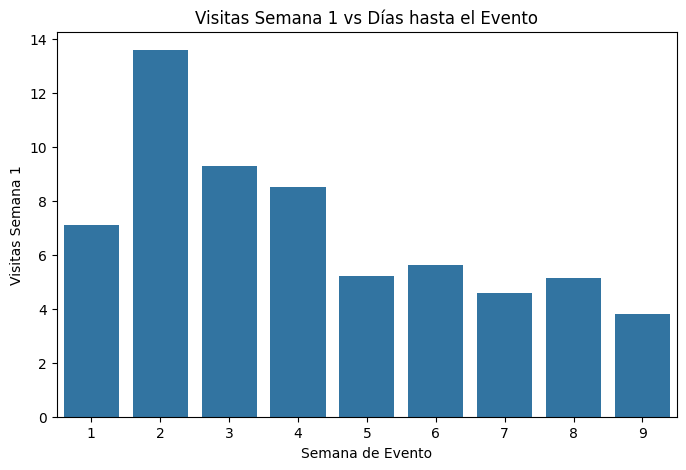

In [57]:
# Filtrado en una sola máscara + .copy() para evitar el SettingWithCopyWarning
mask = dataframe[['days_to_event', 'visitas_semana_1']].copy()

# Variable de semanas con days_to_event
mask['semana_evento'] = pd.cut(
    mask['days_to_event'],
    bins=[0, 7, 14, 21, 28, 35, 42, 49, 56, np.inf],
    labels=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    include_lowest=True
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=mask,
    x='semana_evento', y='visitas_semana_1',
    errorbar=None,          # opcional: oculta las barras de error
)
ax.set_xlabel('Semana de Evento')
ax.set_ylabel('Visitas Semana 1')
ax.set_title('Visitas Semana 1 vs Días hasta el Evento')
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


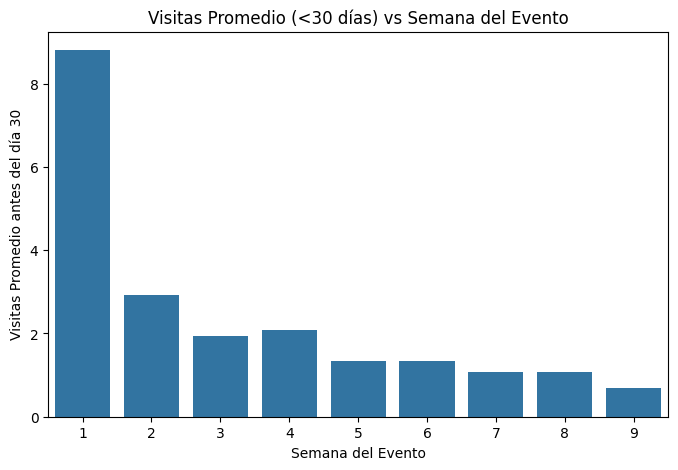

In [12]:
# Filtrado en una sola máscara + .copy() para evitar el SettingWithCopyWarning
mask = dataframe[['days_to_event', 'visita_prom_30']].copy()

# Variable de semanas con days_to_event
mask['semana_evento'] = pd.cut(
    mask['days_to_event'],
    bins=[0, 7, 14, 21, 28, 35, 42, 49, 56, np.inf],
    labels=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    include_lowest=True
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=mask,
    x='semana_evento', y='visita_prom_30',
    errorbar=None,          # opcional: oculta las barras de error
)
ax.set_xlabel('Semana del Evento')
ax.set_ylabel('Visitas Promedio antes del día 30')
ax.set_title('Visitas Promedio (<30 días) vs Semana del Evento')
plt.show()

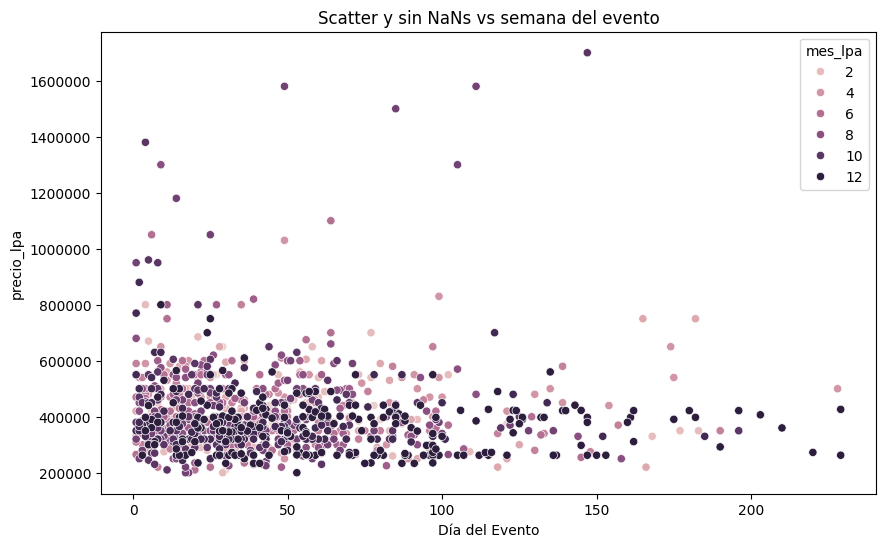

In [33]:

df = dataframe[(dataframe['no_modelo_dias_observados']>0) & (dataframe['year_lpa']==2025)]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='no_modelo_dias_observados', y='precio_lpa', hue='mes_lpa', data=df)
plt.title('Scatter y sin NaNs vs semana del evento')
plt.xlabel('Día del Evento')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [ ]:
# Variables de interés
# y = target
# X = mes_creacion,
#     acepta_mascotas,
#     m2_utiles,
#     m2_utiles**2,
#     piso,
#     comuna,
#     nombre_tipología,
#     mes_LPA,
#     monto_depto,
#     monto_depto**2,
#     reservas,
#     leads,
#     visita_prom_30,
#     visita_prom_30**2,
#     visita_prom_30**3,
#     precio

mtabla = dataframe[[
    'target',
    'created',
    'acepta_mascotas',
    'sector_provincia',
    'm2_utiles',
    'piso',
    'nombre_tipologia',
    'fecha_publicacion_precio',
    'visita_prom_30',
    'visita_prom_30_sqr',
    'owner_type',
    'precio',
    'leads_norm'
]].copy()

mtabla['precio_diezmil'] = mtabla['precio'] / 10000

mtabla['mes_creacion'] = mtabla['created'].dt.month
mtabla['mes_precio'] = mtabla['fecha_publicacion_precio'].dt.month
mtabla = mtabla.drop(columns=['created', 'fecha_publicacion_precio'])
mtabla['piso2'] = mtabla['piso'] ** 2

# Tratar precio = 0 y m2 = 0 como dato faltante para evitar inf y ceros falsos
precio_valido = mtabla['precio'].replace(0, np.nan)
m2_valido = mtabla['m2_utiles'].replace(0, np.nan)
mtabla['precio_m2_miles'] = (precio_valido / m2_valido) / 1000
mtabla['precio_m2_miles_sqr'] = mtabla['precio_m2_miles'] ** 2

#Owner type: 1 si es propietario, 0 si es arrendatario, NaN si no se sabe
mtabla['owner_type'] = np.where(mtabla['owner_type'] == 'new', 1, 0)

mtabla = mtabla.drop(columns=['precio'])

mtabla.describe().round(2)

In [ ]:
# OLS SECTOR/PROVINCIA

def stars(p):
    if p < 0.01:  return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''

for each in mtabla['sector_provincia'].unique():
    Z = mtabla[mtabla['sector_provincia'] == each].drop(columns=['sector_provincia'])

    efectos_fijos = ['mes_creacion', 'mes_precio']
    covariables = [c for c in Z.columns if c != 'target' and c not in efectos_fijos]

    fml = (
        'target ~ '
        + ' + '.join(covariables)
        + ' + ' + ' + '.join(f'C({fe})' for fe in efectos_fijos)
    )

    model = smf.ols(fml, data=Z).fit(cov_type='HC1')

    tabla = pd.DataFrame({
        'coef':    model.params.round(4),
        'std_err': model.bse.round(4),
        't':       model.tvalues.round(3),
        'p_value': model.pvalues.round(4),
        'sig':     model.pvalues.apply(stars),
    })

    print(f"Sector/Provincia: {each}  (n = {len(Z)}, n usado = {int(model.nobs)})")
    print(f"R² = {model.rsquared:.4f}  |  R²-adj = {model.rsquared_adj:.4f}")
    print(tabla.to_string())
    print("Significance: * p<0.10  ** p<0.05  *** p<0.01")
    print("\n")

In [ ]:
#OLS TIPOLOGÍA

def stars(p):
    if p < 0.01:  return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''

for each in mtabla['nombre_tipologia'].unique():
    Z = mtabla[mtabla['nombre_tipologia'] == each].drop(columns=['nombre_tipologia'])

    efectos_fijos = ['mes_creacion', 'mes_precio']
    covariables = [c for c in Z.columns if c != 'target' and c not in efectos_fijos]

    fml = (
        'target ~ '
        + ' + '.join(covariables)
        + ' + ' + ' + '.join(f'C({fe})' for fe in efectos_fijos)
    )

    model = smf.ols(fml, data=Z).fit(cov_type='HC1')

    tabla = pd.DataFrame({
        'coef':    model.params.round(4),
        'std_err': model.bse.round(4),
        't':       model.tvalues.round(3),
        'p_value': model.pvalues.round(4),
        'sig':     model.pvalues.apply(stars),
    })

    print(f"Tipología: {each}  (n = {len(Z)}, n usado = {int(model.nobs)})")
    print(f"R² = {model.rsquared:.4f}  |  R²-adj = {model.rsquared_adj:.4f}")
    print(tabla.to_string())
    print("Significance: * p<0.10  ** p<0.05  *** p<0.01")
    print("\n")

In [ ]:
# OLS INTERACCIONES SECTOR/PROVINCIA - TIPOLOGÍA

cov = dataframe[[
    'target',
    'created',
    'acepta_mascotas',
    'sector_provincia',
    'm2_utiles',
    'piso',
    'nombre_tipologia',
    'fecha_publicacion_precio',
    'visita_prom_30',
    'visita_prom_30_sqr',
    'owner_type',
    'precio',
    'leads_norm'
]].copy()

cov['precio_diezmil'] = cov['precio'] / 10000

cov['mes_creacion'] = cov['created'].dt.month
cov['mes_precio'] = cov['fecha_publicacion_precio'].dt.month
cov = cov.drop(columns=['created', 'fecha_publicacion_precio'])
cov['piso2'] = cov['piso'] ** 2

# Tratar precio = 0 y m2 = 0 como dato faltante para evitar inf y ceros falsos
precio_valido = cov['precio'].replace(0, np.nan)
m2_valido = cov['m2_utiles'].replace(0, np.nan)
cov['precio_m2_miles'] = (precio_valido / m2_valido) / 1000
cov['precio_m2_miles_sqr'] = cov['precio_m2_miles'] ** 2

#Owner type: 1 si es propietario, 0 si es arrendatario, NaN si no se sabe
cov['owner_type'] = np.where(cov['owner_type'] == 'new', 1, 0)

cov = cov.drop(columns=['precio'])

covariables = [
    'acepta_mascotas',
    'm2_utiles',
    'piso',
    'nombre_tipologia',
    'sector_provincia',
    'visita_prom_30',
    'visita_prom_30_sqr',
    'owner_type',
    'precio_diezmil',
    'precio_m2_miles',
    'precio_m2_miles_sqr',
    'leads_norm']

cov['sector_tipo'] = cov['sector_provincia'] + ' | ' + cov['nombre_tipologia']

# 1. Muestra estimable: filas completas y sin infinitos
cols_modelo = ['target', 'sector_tipo', 'mes_creacion', 'mes_precio'] + covariables
base = cov[cols_modelo].copy()

# 2. Agrupar celdas sector_tipo con pocas obs en una categoría residual
MIN_OBS = 10
conteo = base['sector_tipo'].value_counts()
celdas_chicas = conteo[conteo < MIN_OBS].index.tolist()
base['sector_tipo'] = base['sector_tipo'].where(
    ~base['sector_tipo'].isin(celdas_chicas), 'Otras'
)

print(f"Celdas agrupadas en 'Otras' (n < {MIN_OBS}): {len(celdas_chicas)}, "
      f"{(base['sector_tipo'] == 'Otras').sum()} observaciones")

fml = (
    'target ~ C(sector_tipo) + '
    + ' + '.join(covariables)
    + ' + C(mes_creacion) + C(mes_precio)'
)

model_int = smf.ols(fml, data=base).fit(cov_type='HC1')

print(f"\nn usado = {int(model_int.nobs)}")
print(f"Condition number: {model_int.condition_number:,.0f}")
print(model_int.summary())

In [ ]:
# LOGIT TIPOLOGÍA

def stars(p):
    if p < 0.01:  return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''

vars_escalar = ['visita_prom_30', 'visita_prom_30_sqr', 'precio', 'precio_m2', 'm2_utiles', 'piso', 'piso2']

for each in mtabla['nombre_tipologia'].unique():
    Z = mtabla[mtabla['nombre_tipologia'] == each].drop(columns=['nombre_tipologia']).copy()

    for v in vars_escalar:
        if v in Z.columns:
            mu, sigma = Z[v].mean(), Z[v].std()
            if sigma > 0:
                Z[v] = (Z[v] - mu) / sigma

    Z = Z.drop(columns=['visita_prom_30_cub'], errors='ignore')

    covariables = [c for c in Z.columns if c != 'target']
    fml = ('target ~ '
           + ' + '.join(covariables)
           + ' + C(mes_creacion) + C(mes_precio)')

    try:
        model = smf.logit(fml, data=Z).fit(disp=0, maxiter=200)

        mdf = model.get_margeff().summary_frame()
        mdf['sig'] = mdf['Pr(>|z|)'].apply(stars)
        tabla = mdf[['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'sig']].rename(columns={
            'Std. Err.': 'std_err', 'Pr(>|z|)': 'p_value'
        })

        print(f"Tipología: {each}  (n = {len(Z)}, n usado = {int(model.nobs)})")
        print(f"Pseudo-R² (McFadden) = {model.prsquared:.4f}  |  Log-likelihood = {model.llf:.2f}")
        print(tabla.to_string(float_format='{:.6f}'.format))
        print("Marginal effects (dy/dx) at the mean | variables estandarizadas")
        print("Significance: * p<0.10  ** p<0.05  *** p<0.01")

    except Exception as e:
        print(f"Tipología: {each} — modelo no convergió: {e}")

    print("\n")


In [ ]:
# LOGIT SECTOR/PROVINCIA
def stars(p):
    if p < 0.01:  return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''

vars_escalar = ['visita_prom_30', 'visita_prom_30_sqr', 'precio_diezmil',
                'precio_m2_miles', 'precio_m2_miles_sqr', 'm2_utiles', 'piso', 'piso2']

for each in mtabla['sector_provincia'].unique():
    Z = mtabla[mtabla['sector_provincia'] == each].drop(columns=['sector_provincia']).copy()

    for v in vars_escalar:
        if v in Z.columns:
            mu, sigma = Z[v].mean(), Z[v].std()
            if sigma > 0:
                Z[v] = (Z[v] - mu) / sigma

    covariables = [c for c in Z.columns if c not in ['target', 'mes_creacion', 'mes_precio']]
    fml = ('target ~ '
           + ' + '.join(covariables)
           + ' + C(mes_creacion) + C(mes_precio)')

    try:
        model = smf.logit(fml, data=Z).fit(disp=0, maxiter=200)

        mdf = model.get_margeff().summary_frame()
        mdf['sig'] = mdf['Pr(>|z|)'].apply(stars)
        tabla = mdf[['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'sig']].rename(columns={
            'Std. Err.': 'std_err', 'Pr(>|z|)': 'p_value'
        })

        print(f"Sector/Provincia: {each}  (n = {len(Z)}, n usado = {int(model.nobs)})")
        print(f"Pseudo-R² (McFadden) = {model.prsquared:.4f}  |  Log-likelihood = {model.llf:.2f}")
        print(tabla.to_string(float_format='{:.6f}'.format))
        print("Marginal effects (dy/dx) at the mean | variables estandarizadas")
        print("Significance: * p<0.10  ** p<0.05  *** p<0.01")

    except Exception as e:
        print(f"Sector/Provincia: {each} — modelo no convergió: {e}")

    print("\n")


In [ ]:
#LOGIT INTERACCIONES SECTOR/PROVINCIA - TIPOLOGÍA
def stars(p):
    if p < 0.01:  return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''

# Build interaction variable and drop separate sector/tipo columns
base = mtabla.copy()
base['sector_tipo'] = base['sector_provincia'] + ' | ' + base['nombre_tipologia']
base = base.drop(columns=['sector_provincia', 'nombre_tipologia', 'visita_prom_30_cub'], errors='ignore')

# Group small cells to avoid singular matrix
MIN_OBS = 10
conteo = base['sector_tipo'].value_counts()
celdas_chicas = conteo[conteo < MIN_OBS].index.tolist()
base['sector_tipo'] = base['sector_tipo'].where(~base['sector_tipo'].isin(celdas_chicas), 'Otras')
print(f"Celdas agrupadas en 'Otras' (n < {MIN_OBS}): {len(celdas_chicas)},"
      f"{(base['sector_tipo'] == 'Otras').sum()} observaciones")

# Standardize continuous variables
vars_escalar = ['visita_prom_30', 'visita_prom_30_sqr', 'precio', 'precio_m2', 'm2_utiles', 'piso', 'piso2']
for v in vars_escalar:
    if v in base.columns:
        mu, sigma = base[v].mean(), base[v].std()
        if sigma > 0:
            base[v] = (base[v] - mu) / sigma

# Drop rows with NaN in any covariate
base = base.replace([np.inf, -np.inf], np.nan).dropna()

covariables = [c for c in base.columns if c not in ['target', 'sector_tipo','mes_creacion', 'mes_precio']]
fml = 'target ~ C(sector_tipo) + C(mes_creacion) + C(mes_precio) + ' + ' + '.join(covariables)

model = smf.logit(fml, data=base).fit(disp=0, maxiter=200)
mdf = model.get_margeff().summary_frame()
mdf['sig'] = mdf['Pr(>|z|)'].apply(stars)
tabla = mdf[['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'sig']].rename(columns={
    'Std. Err.': 'std_err', 'Pr(>|z|)': 'p_value'
})

print(f"\nn = {int(model.nobs)}")
print(f"Pseudo-R² (McFadden) = {model.prsquared:.4f}  |  Log-likelihood = {model.llf:.2f}")
print(tabla.to_string(float_format='{:.6f}'.format))
print("Marginal effects (dy/dx) at the mean | variables estandarizadas")
print("Significance: * p<0.10  ** p<0.05  *** p<0.01")

In [ ]:
ALPHA = 0.1

vars_escalar = ['visita_prom_30', 'visita_prom_30_sqr', 'precio_diezmil',
                'precio_m2_miles', 'precio_m2_miles_sqr', 'm2_utiles', 'piso', 'piso2']

for each in mtabla['sector_provincia'].unique():
    Z = mtabla[mtabla['sector_provincia'] == each].drop(columns=['sector_provincia']).copy()

    for v in vars_escalar:
        if v in Z.columns:
            mu, sigma = Z[v].mean(), Z[v].std()
            if sigma > 0:
                Z[v] = (Z[v] - mu) / sigma

    Z = Z.replace([np.inf, -np.inf], np.nan).dropna()

    covariables = [c for c in Z.columns if c not in ['target', 'mes_creacion', 'mes_precio']]
    fml = ('target ~ ' + ' + '.join(covariables) + ' + C(mes_creacion) + C(mes_precio)')

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            result = smf.logit(fml, data=Z).fit_regularized(
                method='l1', alpha=ALPHA, L1_wt=1.0, disp=False
            )

        _, X_dm = patsy.dmatrices(fml, data=Z, return_type='dataframe')
        beta   = result.params.values
        p_hat  = expit(X_dm.values @ beta)
        weights = p_hat * (1 - p_hat)

        ape = (weights[:, None] * beta[1:][None, :]).mean(axis=0)

        tabla = pd.DataFrame({
            'coef': result.params.iloc[1:].round(6),
            'APE':  ape.round(6),
        }, index=X_dm.columns[1:])

        print(f"Sector/Provincia: {each}  (n = {len(Z)})  |  L2 alpha = {ALPHA}")
        print(tabla.to_string(float_format='{:.6f}'.format))
        print("APE = Average Partial Effect | variables estandarizadas")
        print("Note: L2 regularization shrinks coefficients — no p-values available")

    except Exception as e:
        print(f"Sector/Provincia: {each} — error: {e}")

    print("\n")


In [ ]:
# LOGIT RIDGE (L2) — modelo poolado
# sklearn LogisticRegression(penalty='l2')
# APE (Average Partial Effect) calculado manualmente
# C = 1/alpha: menor C → mayor penalización

import warnings
import patsy
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning

C_REG = 10.0   # probar 0.1 (fuerte), 1.0 (moderado), 10.0 (leve)

# ── 1. Preparar datos (mismo esquema que la celda de logit poolado)
base_ridge = mtabla.copy()

# Agrupar tipologías con pocas observaciones para evitar separación perfecta
MIN_OBS = 10
conteo_tipo = base_ridge['nombre_tipologia'].value_counts()
tipos_chicos = conteo_tipo[conteo_tipo < MIN_OBS].index.tolist()
base_ridge['nombre_tipologia'] = base_ridge['nombre_tipologia'].where(
    ~base_ridge['nombre_tipologia'].isin(tipos_chicos), 'Otro'
)
if tipos_chicos:
    print(f"Tipologías agrupadas en 'Otro' (n < {MIN_OBS}): {tipos_chicos}")

base_ridge['sector_tipo'] = base_ridge['sector_provincia'] + ' | ' + base_ridge['nombre_tipologia']

# Estandarizar variables continuas
vars_escalar = ['visita_prom_30', 'visita_prom_30_sqr', 'precio_diezmil',
                'precio_m2_miles', 'precio_m2_miles_sqr', 'm2_utiles', 'piso', 'piso2']
for v in vars_escalar:
    if v in base_ridge.columns:
        mu, sigma = base_ridge[v].mean(), base_ridge[v].std()
        if sigma > 0:
            base_ridge[v] = (base_ridge[v] - mu) / sigma

base_ridge = base_ridge.replace([np.inf, -np.inf], np.nan).dropna()

# ── 2. Construir matriz de diseño con patsy (maneja C() y efectos fijos de mes)
covariables = [c for c in base_ridge.columns
               if c not in ['target', 'mes_precio',
                             'sector_provincia', 'nombre_tipologia', 'sector_tipo']]

fml = ('target ~ C(sector_provincia) + C(nombre_tipologia) + C(sector_tipo) + '
       + ' + '.join(covariables)
       + ' + C(mes_precio)')

y_mat, X_dm = patsy.dmatrices(fml, data=base_ridge, return_type='dataframe')
y        = y_mat.values.ravel().astype(int)
X        = X_dm.values
var_names = X_dm.columns.tolist()

# ── 3. Ajustar Ridge Logit
with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    lr = LogisticRegression(
        penalty='l2',
        C=C_REG,
        solver='lbfgs',
        max_iter=1000,
        fit_intercept=False   # el intercept ya está en X_dm como columna 'Intercept'
    )
    lr.fit(X, y)

beta = lr.coef_[0]

# ── 4. Average Partial Effects: APE_j = mean_i[ p_i*(1-p_i) ] * beta_j
p_hat   = expit(X @ beta)
weights = p_hat * (1 - p_hat)
ape     = (weights[:, None] * beta[None, :]).mean(axis=0)

acc = (lr.predict(X) == y).mean()

# ── 5. Mostrar resultados
tabla = pd.DataFrame({
    'coef (log-odds)': beta.round(5),
    'APE':             ape.round(5),
}, index=var_names)

print(f"LOGIT RIDGE (L2)  |  C = {C_REG} (alpha = {1/C_REG:.2f})  |  n = {len(y)}")
print(f"Accuracy in-sample = {acc:.4f}  |  Prevalencia target=1 = {y.mean():.4f}")
print(f"\nVariables continuas estandarizadas — APE = Δ P(target=1) ante +1σ")
print("="*65)
print(tabla.to_string(float_format='{:.5f}'.format))
print("\nNota: L2 contrae coeficientes hacia 0 — no hay p-values estándar")

In [ ]:

import warnings
import patsy
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning

C_REG = 0.1

base_ridge = mtabla.copy()
base_ridge['sector_tipo'] = base_ridge['sector_provincia'] + ' | ' + base_ridge['nombre_tipologia']

MIN_OBS = 10
conteo = base_ridge['sector_tipo'].value_counts()
celdas_chicas = conteo[conteo < MIN_OBS].index.tolist()
base_ridge['sector_tipo'] = base_ridge['sector_tipo'].where(
    ~base_ridge['sector_tipo'].isin(celdas_chicas), 'Otras'
)
print(f"Celdas agrupadas en 'Otras' (n < {MIN_OBS}): {len(celdas_chicas)}, "
      f"{(base_ridge['sector_tipo'] == 'Otras').sum()} observaciones")

vars_escalar = ['visita_prom_30', 'visita_prom_30_sqr', 'precio_diezmil',
                'precio_m2_miles', 'precio_m2_miles_sqr', 'm2_utiles', 'piso', 'piso2']
for v in vars_escalar:
    if v in base_ridge.columns:
        mu, sigma = base_ridge[v].mean(), base_ridge[v].std()
        if sigma > 0:
            base_ridge[v] = (base_ridge[v] - mu) / sigma

base_ridge = base_ridge.replace([np.inf, -np.inf], np.nan).dropna()

covariables = [c for c in base_ridge.columns
               if c not in ['target', 'mes_creacion', 'mes_precio',
                             'sector_provincia', 'nombre_tipologia', 'sector_tipo']]

fml = ('target ~ C(sector_tipo) + '
       + ' + '.join(covariables)
       + ' + C(mes_precio)')

y_mat, X_dm = patsy.dmatrices(fml, data=base_ridge, return_type='dataframe')
y         = y_mat.values.ravel().astype(int)
X         = X_dm.values
var_names = X_dm.columns.tolist()

with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    lr = LogisticRegression(C=C_REG, l1_ratio=0, solver='lbfgs',
                            max_iter=1000, fit_intercept=False)
    lr.fit(X, y)

beta    = lr.coef_[0]
p_hat   = expit(X @ beta)
weights = p_hat * (1 - p_hat)
ape     = (weights[:, None] * beta[None, :]).mean(axis=0)
acc     = (lr.predict(X) == y).mean()

tabla = pd.DataFrame({
    'coef (log-odds)': beta.round(5),
    'APE':             ape.round(5),
}, index=var_names)

print(f"\nLOGIT RIDGE (L2) con interacción sector × tipología")
print(f"C = {C_REG} (alpha = {1/C_REG:.2f})  |  n = {len(y)}")
print(f"Accuracy in-sample = {acc:.4f}  |  Prevalencia target=1 = {y.mean():.4f}")
print(f"\nVariables continuas estandarizadas — APE = Δ P(target=1) ante +1σ")
print("="*65)
print(tabla.to_string(float_format='{:.5f}'.format))
print("\nNota: L2 contrae coeficientes hacia 0 — no hay p-values estándar")

# Sacar T.Santiago - Centro | 1D1B
# Agregar leads y agendas normalizadas
# Cotizaciones (talvez)


# lead attempts - cada vez que se selecciona un departamento pero diferencia si la persona miro en distintos momentos.

In [ ]:

from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve

y_prob = p_hat
y_true = y

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Logit Ridge (L2) — Predicción vs Datos Reales  |  C={C_REG}', fontsize=13)

# ── 1. Distribución de probabilidades predichas por clase real
ax = axes[0, 0]
ax.hist(y_prob[y_true == 0], bins=40, alpha=0.6, color='steelblue', label='target = 0 (lento)')
ax.hist(y_prob[y_true == 1], bins=40, alpha=0.6, color='tomato',    label='target = 1 (rápido)')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='umbral 0.5')
ax.set_xlabel('P(target = 1) predicha')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de probabilidades predichas')
ax.legend()

# ── 2. Curva ROC
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC')
ax.legend()

# ── 3. Curva de calibración
ax = axes[1, 0]
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
ax.plot(prob_pred, prob_true, marker='o', color='seagreen', label='Modelo Ridge')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibración perfecta')
ax.set_xlabel('Probabilidad predicha promedio')
ax.set_ylabel('Fracción de positivos reales')
ax.set_title('Curva de Calibración')
ax.legend()

# ── 4. Predicciones ordenadas vs target real
ax = axes[1, 1]
idx_sort = np.argsort(y_prob)
sample   = np.linspace(0, len(idx_sort) - 1, 300, dtype=int)
idx_s    = idx_sort[sample]
ax.scatter(range(len(idx_s)), y_prob[idx_s], c=y_true[idx_s],
           cmap='RdBu_r', s=12, alpha=0.7)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='umbral 0.5')
ax.set_xlabel('Observación (ordenada por prob. predicha)')
ax.set_ylabel('P(target = 1) predicha')
ax.set_title('Prob. predicha ordenada — color = clase real\n(azul=0, rojo=1)')
ax.legend()

plt.tight_layout()
plt.show()

from sklearn.metrics import classification_report
thresh = 0.4
y_pred = (y_prob >= thresh).astype(int)
print(f"\nClasificación con umbral {thresh}:")
print(classification_report(y_true, y_pred, target_names=['Lento (0)', 'Rápido (1)']))
print(f"AUC-ROC = {roc_auc:.4f}")


In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Lento (0)', 'Rápido (1)'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()